# 05 — NLP Feature Ablation Study (Experiments A–D)

**Research comparison only.** This notebook produces evidence for the
dissertation's discussion of whether NLP-derived features are worth adding to
the deployed pipeline. It does **not** retrain, replace, or modify
`ml_pipeline/artifacts/stress_model_v2.pkl` or anything `backend/app/`
loads, and nothing here is imported by the backend. Every result is logged
under `ml_pipeline/experiments/` using the same `log_experiment()` pattern as
every other experiment in this project.

## Why this notebook exists

Chapter 2 frames NLP-derived conversational features (sentiment, emotion,
keyword extraction) as part of the eventual system. Before building that into
anything deployed, the ablation question needs an honest answer: does adding
text-derived signal actually help, and — a prior question the brief did not
originally surface — **can it even be tested on data that exists today?**

## The four intended conditions, and why only two run here

| # | Condition | Status |
|---|---|---|
| A | Questionnaire only | **Reference only** — the existing, fully-evaluated v2 Random Forest. Not retrained here. |
| B | NLP only | **Run in this notebook** — TF-IDF + Logistic Regression on Dreaddit. |
| C | Questionnaire + NLP, combined | **Not executable** — see below. |
| D | *(reserved: combined + tuning/feature-selection variant)* | **Not executable** — same reason as C. |

**Why C and D cannot run on data available today.** A combined model needs a
single respondent who provided both a structured questionnaire response and
free text. The Kaggle dataset behind Experiment A has no text field at all.
Dreaddit (Experiment B) has text but none of the 14 questionnaire features.
They are different people, recruited on different platforms, with no shared
identifier — there is no row where both exist together.

**Deliberately not attempted**: pairing a random Kaggle respondent's answers
with a random Dreaddit post's text to manufacture a "combined" row. That would
fabricate a relationship between two unrelated people. Per the discussion
already in `docs/decisions/ADR.md` (ADR-003) and `docs/research/methodology.md`,
this project treats data-integrity shortcuts as a documented methodological
hazard to avoid, not a workaround for one — inventing a cross-subject pairing
here would be a worse version of exactly that hazard, not a fix for the
questionnaire dataset's leakage problem.

**What would make C/D possible**: the project's own Phase 8 locally-collected
data (`docs/governance/data_management_plan.md`) is the only data source that
structurally supports this, because it collects both a Likert-style
questionnaire *and* an open-ended free-text field ("what's the biggest factor
currently affecting your stress?") from the **same** respondent. C and D are
therefore recorded here as a planned future analysis, contingent on enough
Phase 8 responses, not as an abandoned experiment.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

from src.experiments.logger import hash_file, log_experiment
from src.nlp.dreaddit import (
    evaluate_binary_classifier,
    load_dreaddit,
    train_tfidf_logreg_with_cv,
)
from src.nlp.lexicon_scores import compute_textblob_scores, compute_vader_scores

TRAIN_PATH = "../datasets/raw/dreaddit-train.csv"
TEST_PATH = "../datasets/raw/dreaddit-test.csv"
EXPERIMENTS_DIR = "../experiments"
RANDOM_STATE = 42
CV_SCORING = "f1_macro"

## Experiment A — questionnaire-only (reference, not retrained)

Read directly from the artifacts already produced by `03_ModelTraining.ipynb`
and `04_SHAPAnalysis.ipynb`. This cell trains nothing.

In [2]:
manifest = json.loads(Path("../artifacts/artifact_manifest.json").read_text(encoding="utf-8"))

print("Experiment A — reference only (source: ml_pipeline/artifacts/artifact_manifest.json)")
print(f"  Model               : {manifest['selected_model']} ({manifest['model_version']})")
print(f"  Training dataset     : {manifest['training_dataset']['path']}")
print(f"  Features used        : {manifest['training_dataset']['features_used']} "
      f"(excluded for leakage: {manifest['training_dataset']['features_excluded_for_leakage']})")
print(f"  Target                : 3-class stress_level (0 low / 1 moderate / 2 high)")
print("  Held-out test metrics:")
for k, v in manifest["holdout_test_metrics"].items():
    print(f"    {k:20s} {v:.4f}")

Experiment A — reference only (source: ml_pipeline/artifacts/artifact_manifest.json)
  Model               : RandomForestClassifier (v2)
  Training dataset     : ../datasets/raw/student_stress_factors.csv
  Features used        : 14 (excluded for leakage: ['sleep_quality', 'future_career_concerns', 'blood_pressure', 'depression', 'bullying', 'anxiety_level'])
  Target                : 3-class stress_level (0 low / 1 moderate / 2 high)
  Held-out test metrics:
    accuracy             0.8818
    balanced_accuracy    0.8821
    precision_macro      0.8824
    recall_macro         0.8821
    f1_macro             0.8815
    roc_auc_macro_ovr    0.9838


## Experiment B — NLP-only, TF-IDF + Logistic Regression on Dreaddit

Uses Dreaddit's own official train/test split and its own binary label — no
re-splitting, no relabelling, no connection to the Kaggle questionnaire data.

In [3]:
X_train_text, y_train, X_test_text, y_test = load_dreaddit(TRAIN_PATH, TEST_PATH)

print(f"Dreaddit train: {len(X_train_text)} posts, test: {len(X_test_text)} posts")
print("\nTrain label balance (0 = not stressed, 1 = stressed):")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest label balance:")
print(y_test.value_counts(normalize=True).round(3))
print(f"\nText length (chars), train: mean={X_train_text.str.len().mean():.0f}, "
      f"median={X_train_text.str.len().median():.0f}")

Dreaddit train: 2838 posts, test: 715 posts

Train label balance (0 = not stressed, 1 = stressed):
label
1    0.524
0    0.476
Name: proportion, dtype: float64

Test label balance:
label
1    0.516
0    0.484
Name: proportion, dtype: float64

Text length (chars), train: mean=448, median=421


In [4]:
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

b_search = train_tfidf_logreg_with_cv(
    X_train_text, y_train, cv=CV_STRATEGY, random_state=RANDOM_STATE, scoring=CV_SCORING
)
print(f"Best params: {b_search.best_params_}")
print(f"Best CV {CV_SCORING}: {b_search.best_score_:.4f}")

Best params: {'logreg__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
Best CV f1_macro: 0.7397


Experiment B — held-out Dreaddit test metrics:
  accuracy             0.7007
  balanced_accuracy    0.6989
  precision_macro      0.7017
  recall_macro         0.6989
  f1_macro             0.6989
  roc_auc              0.7974



        pred_0  pred_1
true_0     223     123
true_1      91     278


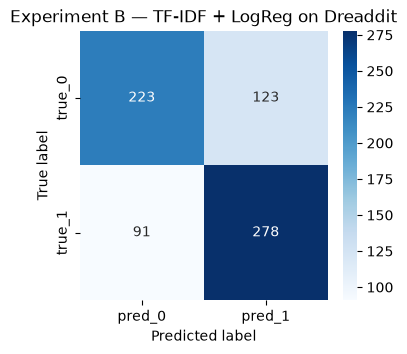

In [5]:
b_model = b_search.best_estimator_
y_pred = b_model.predict(X_test_text)
y_score_pos = b_model.predict_proba(X_test_text)[:, 1]

b_metrics = evaluate_binary_classifier(y_test, y_pred, y_score_positive=y_score_pos, labels=(0, 1))

print("Experiment B — held-out Dreaddit test metrics:")
for k, v in b_metrics.items():
    if k == "confusion_matrix":
        continue
    print(f"  {k:20s} {v:.4f}")

cm = pd.DataFrame(b_metrics["confusion_matrix"], index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
print()
print(cm)

plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Experiment B — TF-IDF + LogReg on Dreaddit")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

In [6]:
log_path_b = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="ablation_B_nlp_only_tfidf_logreg_dreaddit",
    model_name=type(b_model.named_steps["logreg"]).__name__,
    hyperparameters=b_model.get_params(),
    dataset_path=TRAIN_PATH,
    split_info={
        "protocol": "Dreaddit official train/test split (not re-split)",
        "cv_folds": CV_STRATEGY.get_n_splits(),
        "cv_scoring": CV_SCORING,
        "cv_best_score": float(b_search.best_score_),
        "train_rows": int(len(X_train_text)),
        "test_rows": int(len(X_test_text)),
        "test_dataset_path": TEST_PATH,
        "test_dataset_sha256": hash_file(TEST_PATH),
        "ablation_condition": "B",
        "not_comparable_to": "Experiment A (different dataset, population, and label scheme)",
    },
    metrics=b_metrics,
)
print(f"Logged to: {log_path_b}")

Logged to: ../experiments/20260816T080647Z_ablation_B_nlp_only_tfidf_logreg_dreaddit.json


## Descriptive sentiment scoring (VADER, TextBlob)

Reported to characterise the text, **not** used as model features anywhere —
Experiment B above is TF-IDF + Logistic Regression on raw text only.

In [7]:
vader_scores = compute_vader_scores(X_train_text)
textblob_scores = compute_textblob_scores(X_train_text)

lexicon_df = pd.concat(
    [vader_scores, textblob_scores, y_train.reset_index(drop=True).rename("label")], axis=1
)

print("Mean lexicon scores by Dreaddit label (0 = not stressed, 1 = stressed):")
print(lexicon_df.groupby("label").mean().round(4).to_string())

print("\nVADER compound score is designed to range from -1 (most negative) to +1 (most positive);")
print("TextBlob polarity is -1 to +1, subjectivity is 0 (objective) to 1 (subjective).")

Mean lexicon scores by Dreaddit label (0 = not stressed, 1 = stressed):
       vader_neg  vader_neu  vader_pos  vader_compound  textblob_polarity  textblob_subjectivity
label                                                                                           
0         0.0688     0.8133     0.1179          0.2710             0.1031                 0.4716
1         0.1349     0.7800     0.0851         -0.3061            -0.0158                 0.5045

VADER compound score is designed to range from -1 (most negative) to +1 (most positive);
TextBlob polarity is -1 to +1, subjectivity is 0 (objective) to 1 (subjective).


/tmp/ipykernel_7119/322618813.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["not stressed (0)", "stressed (1)"])
/tmp/ipykernel_7119/322618813.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["not stressed (0)", "stressed (1)"])


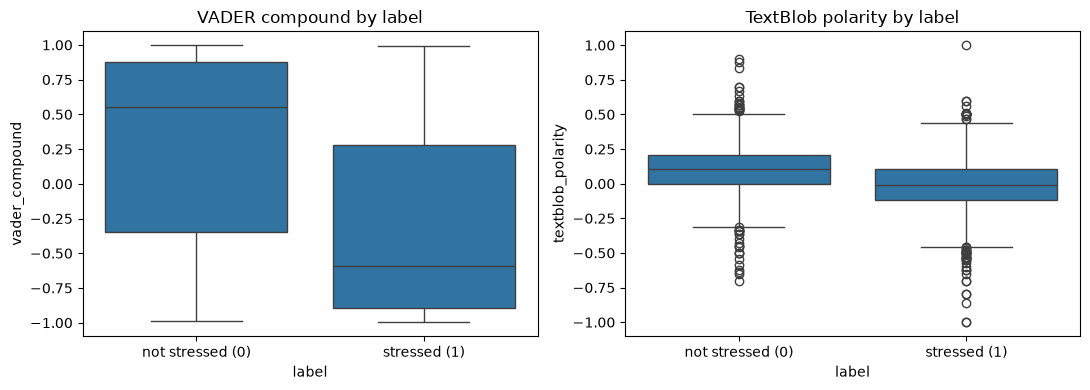

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=lexicon_df, x="label", y="vader_compound", ax=axes[0])
axes[0].set_title("VADER compound by label")
axes[0].set_xticklabels(["not stressed (0)", "stressed (1)"])

sns.boxplot(data=lexicon_df, x="label", y="textblob_polarity", ax=axes[1])
axes[1].set_title("TextBlob polarity by label")
axes[1].set_xticklabels(["not stressed (0)", "stressed (1)"])

plt.tight_layout()
plt.show()

## Experiment A vs. Experiment B — explicitly NOT a comparison table

The two are reported side by side for reference. They must not be read as
"model X beat model Y" — they differ on every axis that would make such a
reading valid.

In [9]:
comparison = pd.DataFrame(
    {
        "Experiment A (reference)": {
            "dataset": "Kaggle student_stress_factors.csv",
            "population": "University student survey respondents",
            "n_test": 220,
            "target": "3-class (low/moderate/high)",
            "input": "14 Likert-style questionnaire features",
            "accuracy": manifest["holdout_test_metrics"]["accuracy"],
            "f1_macro": manifest["holdout_test_metrics"]["f1_macro"],
        },
        "Experiment B": {
            "dataset": "Dreaddit (Reddit posts)",
            "population": "Reddit users across stress-related subreddits",
            "n_test": len(X_test_text),
            "target": "binary (not stressed / stressed)",
            "input": "raw post text (TF-IDF)",
            "accuracy": b_metrics["accuracy"],
            "f1_macro": b_metrics["f1_macro"],
        },
    }
)
print(comparison.to_string())
print()
print("NOT COMPARABLE: different datasets, different populations, different")
print("label schemes (3-class vs. binary). Any numeric similarity or difference")
print("between the accuracy/F1 rows above is not evidence about which approach")
print("is \"better\" - the two numbers do not answer the same question.")

                          Experiment A (reference)                                   Experiment B
dataset          Kaggle student_stress_factors.csv                        Dreaddit (Reddit posts)
population   University student survey respondents  Reddit users across stress-related subreddits
n_test                                         220                                            715
target                 3-class (low/moderate/high)               binary (not stressed / stressed)
input       14 Likert-style questionnaire features                         raw post text (TF-IDF)
accuracy                                  0.881818                                       0.700699
f1_macro                                   0.88151                                       0.698918

NOT COMPARABLE: different datasets, different populations, different
label schemes (3-class vs. binary). Any numeric similarity or difference
between the accuracy/F1 rows above is not evidence about which approach
i

## Experiments C and D — not currently executable (documented finding)

**This is a methodological finding, not a skipped step.**

No available public dataset pairs structured questionnaire responses with
free text from the *same* subjects, so a genuine combined-feature model
cannot be trained or evaluated on public data at this time. The two datasets
used above are the best available proxies for questionnaire-only and
NLP-only signal respectively, but neither — nor any pairing of the two —
supports a combined condition without fabricating a cross-subject
relationship that does not exist in reality.

**Path forward, already designed into this project**: `docs/governance/
data_management_plan.md` specifies a locally-collected instrument (Phase 8)
combining a Likert-style questionnaire with an open-ended free-text prompt
("what's the biggest factor currently affecting your stress?") from the same
respondent. That is the only data source that structurally supports
Experiments C and D. They are recorded here as a **planned future analysis**,
contingent on collecting a sufficient number of Phase 8 responses — not as an
abandoned line of work.

**Consequence for any future integration decision**: if C/D later show NLP
features meaningfully improve on Experiment A once genuinely combined data
exists, integrating that into the deployed pipeline is a separate decision to
be made explicitly, not an automatic next step from this notebook.